## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
!hostname

ne1dg6-005.nygenome.org


In [2]:
import os
import pandas as pd 
from sklearn.decomposition import TruncatedSVD
import anndata as ad
from scipy.sparse import coo_matrix, csr_matrix
from datetime import datetime

# turn this into AnnData object 
import anndata as ad
import numpy as np
import torch 
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from scipy.spatial.distance import cdist

import numpy as np

import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
import scipy.sparse
import datetime
import sys
import random

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
# from visualize_ATSE import visualize_local_events

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import BetaDirichletFactor.waypoints as wayp

# Add path to where find_intron_clusters_v3.py is located 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering')
from find_intron_clusters_v3 import JunctionReader

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

!hostname

Torch Version: 2.4.1.post300
CUDA Version: 12.0
Using device: cuda
ne1dg6-005.nygenome.org


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


### Specify if we want to prep brain only file or ALL tissue file


In [3]:
brain_only=False
gtf_annot=True

In [4]:
# input_file='/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_Object_20240927_214100.h5ad' 
# input_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_noGTF_Object_20250123_232044.h5ad"
input_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/junction_processing_20250324/merged_anndata.h5ad"

splice_adata = ad.read_h5ad(input_file)
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index 

print(f"The number of cells in the dataset is {splice_adata.shape[0]}")

The number of cells in the dataset is 106182


In [5]:
# Note: this ATSE file was also generated through the script mentioned above
# ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/tabula_senis_test_intron_clusters_50_500000_10_20240927_single_cell.gz"
# ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/tabula_senis_annotationFREE_intron_clusters_50_500000_100_20250123_single_cell.gz"
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-03-25_10-58-09.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")

In [47]:
atses

,event_id,gene_id,gene_name,gene_types,transcripts,both_ends_transcripts,only_5_prime_transcripts,only_3_prime_transcripts,transcript_types,num_junctions,...,three_prime_usage,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSMUSG00000033813.15,Tcea1,protein_coding,"ENSMUST00000081551.13,ENSMUST00000165720.2",NaN,NaN,"ENSMUST00000081551.13,ENSMUST00000165720.2",protein_coding,2,...,1.0000,0.1205,1.0000,948069,114240,GT-AG,GT,AG,0.0,-2.0
1,ATSE_0,ENSMUSG00000033813.15,Tcea1,protein_coding,"ENSMUST00000081551.13,ENSMUST00000165720.2",NaN,NaN,"ENSMUST00000081551.13,ENSMUST00000165720.2",protein_coding,2,...,1.0000,0.8795,1.0000,948069,833829,GT-AG,GT,AG,0.0,1.0
2,ATSE_1,ENSMUSG00000033793.12,Atp6v1h,protein_coding,"ENSMUST00000192847.5,ENSMUST00000194301.5,ENSM...",NaN,NaN,"ENSMUST00000192847.5,ENSMUST00000194301.5,ENSM...","protein_coding,retained_intron",2,...,1.0000,0.9412,1.0000,547457,515276,GT-AG,GT,AG,0.0,1.0
3,ATSE_1,ENSMUSG00000033793.12,Atp6v1h,protein_coding,"ENSMUST00000192847.5,ENSMUST00000194301.5,ENSM...",NaN,NaN,"ENSMUST00000192847.5,ENSMUST00000194301.5,ENSM...","protein_coding,retained_intron",2,...,0.0588,1.0000,0.0588,32181,547457,GT-AG,GT,AG,0.0,1.0
4,ATSE_2,ENSMUSG00000033793.12,Atp6v1h,protein_coding,"ENSMUST00000192847.5,ENSMUST00000192698.2,ENSM...",NaN,NaN,"ENSMUST00000192847.5,ENSMUST00000192698.2,ENSM...","protein_coding,retained_intron",3,...,0.9807,1.0000,0.9807,873106,890303,GT-AG,GT,AG,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21536,ATSE_7856,ENSMUSG00000072591.10,5930412G12Rik,lincRNA,"ENSMUST00000091324.10,ENSMUST00000134673.7,ENS...","ENSMUST00000091324.10,ENSMUST00000134673.7,ENS...",ENSMUST00000140028.7,NaN,lincRNA,2,...,0.5906,0.5906,1.0000,26507,15655,GT-AG,GT,AG,1.0,0.0
21537,ATSE_7856,ENSMUSG00000072591.10,5930412G12Rik,lincRNA,"ENSMUST00000091324.10,ENSMUST00000134673.7,ENS...","ENSMUST00000091324.10,ENSMUST00000154305.7,ENS...","ENSMUST00000134673.7,ENSMUST00000126472.1",NaN,lincRNA,2,...,0.4094,0.4094,1.0000,26507,10852,GT-AG,GT,AG,1.0,0.0
21538,ATSE_7857,ENSMUSG00000041707.8,Tmem273,protein_coding,"ENSMUST00000039191.7,ENSMUST00000227060.1,ENSM...",NaN,NaN,"ENSMUST00000039191.7,ENSMUST00000227060.1,ENSM...","protein_coding,nonsense_mediated_decay",3,...,0.8354,1.0000,0.8354,202873,242841,GT-AG,GT,AG,0.0,1.0
21539,ATSE_7857,ENSMUSG00000041707.8,Tmem273,protein_coding,"ENSMUST00000039191.7,ENSMUST00000227871.1",NaN,NaN,"ENSMUST00000039191.7,ENSMUST00000227871.1","protein_coding,nonsense_mediated_decay",3,...,1.0000,0.8102,1.0000,210541,170573,GT-AG,GT,AG,0.0,1.0


In [6]:
if brain_only:
    splice_adata = splice_adata[splice_adata.obs["tissue"].isin(["Brain_Myeloid", "Brain_Non-Myeloid"])]
    splice_adata.obs.reset_index(drop=True, inplace=True)
    splice_adata.obs["cell_id_index"] = splice_adata.obs.index 
    print(splice_adata.obs.shape, splice_adata.obs.cell_id_index.max())

In [7]:
splice_adata.obs["age"].value_counts()

age
3m     41739
18m    33128
24m    31315
Name: count, dtype: int64

##### Clean up Cell IDs in the splicing Anndata object so can merge them with the IDs in the gene expression object

In [8]:
splice_adata.obs["cell_clean"] = splice_adata.obs["cell_id"].str.replace(r'-(?=.*_)', '_', regex=True).values
splice_adata.obs["cell_clean"] = splice_adata.obs["cell_clean"].str.split('_').str[:2].str.join('_')
print(f"The number of cells in the dataset is {splice_adata.shape[0]}")

The number of cells in the dataset is 106182


#### Figure out which junctions to include for model training object

In [9]:
splice_adata.var["non_zero_count_cells"] = np.array((splice_adata.X > 0).sum(axis=0)).flatten()
splice_adata.var["non_zero_cell_prop"] = splice_adata.var["non_zero_count_cells"] / splice_adata.shape[0]

In [10]:
# let's make an ATSE event id score to decide which ATSEs to keep at the end, since we are limited to under 100,000 splice junctions 
# what do we care about? 
# - number of fully annotated splice junctions in the ATSE vs partially annotated vs unannotated (annotation_status)
# - number of cells that have splice junctions in this ATSE expressed above zero (non_zero_cell_prop)
# - which splice_motif is used in the ATSE (splice_motif)

# let's make a score for each ATSE based on these three criteria 
# - annotation_status: 1 for fully annotated, 0.5 for partially annotated, 0 for unannotated
# - non_zero_cell_prop: 1 if non_zero_cell_prop > 0.01, 0 otherwise
# - splice_motif: 1 if splice_motif is "GT-AG", 0 otherwise

# let's calculate these for every junction and combine and normalize score per ATSE event_id 
splice_adata.var["annotation_status_score"] = splice_adata.var["annotation_status"].map({"both": 1, "five_prime": 0.5, "three_prime": 0.5, "unannotated": 0})
splice_adata.var["non_zero_cell_prop_score"] = (splice_adata.var["non_zero_cell_prop"] > 0.01).astype(int)
splice_adata.var["splice_motif_score"] = (splice_adata.var["splice_motif"] == "GT-AG").astype(int)

# weigh the annotation_status_score more heavily than the other two scores 
splice_adata.var["annotation_status_score"] *= 2
splice_adata.var["non_zero_cell_prop_score"] *= 1.5

# Combine and normalize score per ATSE event_id 
# First group by event_id and sum the scores before normalizing by the number of junctions in the event_id
atse_scores = splice_adata.var.groupby("event_id")[
    ["annotation_status_score", "non_zero_cell_prop_score"]
].sum()

# Normalize by the number of junctions in each event_id
junction_counts = splice_adata.var["event_id"].value_counts().rename("junction_count")

# Add the three columns to make ATSE_score 
atse_scores["atse_score"] = atse_scores.sum(axis=1)
atse_scores["number_of_junctions"] = junction_counts
atse_scores["normalized_atse_score"] = atse_scores["atse_score"] / junction_counts
atse_scores.sort_values("number_of_junctions", ascending=False).head()

/scratch/ipykernel_2291680/4098449752.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  atse_scores = splice_adata.var.groupby("event_id")[


,annotation_status_score,non_zero_cell_prop_score,atse_score,number_of_junctions,normalized_atse_score
event_id,,,,,
ATSE_6141,0.0,9.0,9.0,38,0.236842
ATSE_7724,0.0,6.0,6.0,38,0.157895
ATSE_1999,25.0,33.0,58.0,25,2.320000
ATSE_6139,0.0,16.5,16.5,18,0.916667
ATSE_7153,0.0,9.0,9.0,17,0.529412


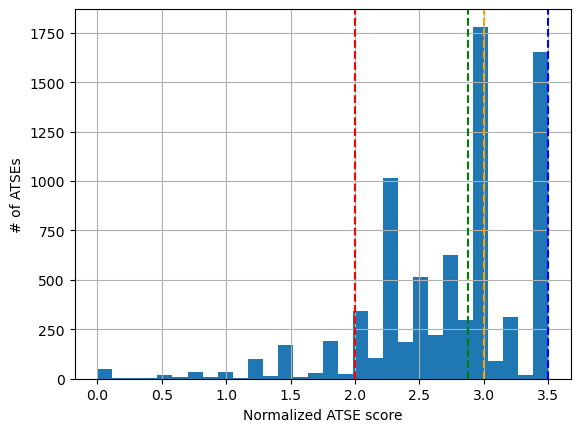

Number of ATSEs remaining at 10th percentile: 6822
Number of ATSEs remaining at 50th percentile: 3887
Number of ATSEs remaining at 60th percentile: 2073
Number of ATSEs remaining at 90th percentile: 0


In [11]:
# summarize histogram of normalized_atse_score show percentilues 10% 50% 90% 
atse_scores["normalized_atse_score"].describe(percentiles=[0.1, 0.5, 0.6, 0.9])
# make a histogram of the normalized_atse_score 
atse_scores["normalized_atse_score"].hist(bins=30)

# draw dashed lines for the percentiles 
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.1), color="red", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.5), color="green", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.6), color="orange", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.9), color="blue", linestyle="--")

# add xlaxis and yaxis labels 
plt.xlabel("Normalized ATSE score")
plt.ylabel("# of ATSEs")
plt.show()

# Print how many ATSEs remain after filtering at each of the percentiles
print(f"Number of ATSEs remaining at 10th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.1)].shape[0]}")
print(f"Number of ATSEs remaining at 50th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.5)].shape[0]}")
print(f"Number of ATSEs remaining at 60th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.6)].shape[0]}")
print(f"Number of ATSEs remaining at 90th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.9)].shape[0]}")


In [12]:
# For splice_adata object, let's filter out the ATSEs that have a normalized_atse_score below the 10th percentile
atse_scores_filt = atse_scores[atse_scores["normalized_atse_score"] > atse_scores["normalized_atse_score"].quantile(0.2)]
splice_adata = splice_adata[:, splice_adata.var["event_id"].isin(atse_scores_filt.index)]

# print remaining number of atses 
print(f"The number of junctions in the dataset is {splice_adata.shape[1]}")

The number of junctions in the dataset is 16221


In [13]:
if gtf_annot:
    # find common columns between splice_adata.var and atses
    splice_adata.var = splice_adata.var.merge(atses[["gene_id", "gene_name", "junction_id", "annotation_status", "position_off_5_prime", "position_off_3_prime"]], on=["junction_id", "gene_id", "annotation_status", "gene_name", "position_off_5_prime", "position_off_3_prime"])
else:
    splice_adata.var = splice_adata.var.merge(atses[["junction_id"]], on=["junction_id"])    

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
splice_adata.var.reset_index(drop=True, inplace=True)
# Rename the old junction_id_index to old_junction_id_index 
splice_adata.var.rename(columns={'junction_id_index': 'old_junction_id_index'}, inplace=True)
# Redo the junction_id_index column now that we have removed some junctions
splice_adata.var['junction_id_index'] = splice_adata.var.index
splice_adata.var.head()

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,junction_id_index
0,chr10_100080130_100080856_+,ATSE_5301,GT-AG,both,Kitl,ENSMUSG00000019966.18,3,0.0,1.0,170647,0,3544,0.033377,2.0,1.5,1,0
1,chr10_100080130_100087346_+,ATSE_5301,GT-AG,both,Kitl,ENSMUSG00000019966.18,3,0.0,1.0,110948,1,2543,0.023949,2.0,1.5,1,1
2,chr10_100080940_100087346_+,ATSE_5301,GT-AG,both,Kitl,ENSMUSG00000019966.18,3,0.0,1.0,151891,2,3425,0.032256,2.0,1.5,1,2
3,chr10_100478022_100485050_-,ATSE_5646,GT-AG,both,Tmtc3,ENSMUSG00000036676.14,2,1.0,0.0,7109,3,535,0.005039,2.0,0.0,1,3
4,chr10_100478022_100487161_-,ATSE_5646,GT-AG,both,Tmtc3,ENSMUSG00000036676.14,2,1.0,0.0,36154,4,2144,0.020192,2.0,1.5,1,4


### Load in gene expression matrix for smart-seq2 data and align cell IDs 

In [15]:
# Load the expression data (.h5ad file)
exp_file = "/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/processed_for_scanpy/tabulamurissenisfacsofficialrawobj.h5ad"
adata = sc.read_h5ad(exp_file)

# Reset the index of adata.obs to integers and drop the old index
adata.obs.reset_index(drop=True, inplace=True)
adata.var["mouse_gene_name"] = adata.var.index

# Clean up Cell IDs in the gene expression object
# If age column is 3m, adjust cell_clean to replace the first "." with "_" and the second "." also with "_" (annoying fix but that's how the data came...)
adata.obs['cell_clean'] = adata.obs['cell']  # Start by copying the 'cell' column to 'cell_clean'
adata.obs.loc[adata.obs['age'] == '3m', 'cell_clean'] = adata.obs.loc[adata.obs['age'] == '3m', 'cell'].str.replace('.', '_', 2)
adata.obs["cell_clean"] = adata.obs["cell_clean"].str.split('_').str[:2].str.join('_') 
print(f"The number of cells in the expression dataset is {adata.shape[0]}")

The number of cells in the expression dataset is 110824


### Make Cell IDs comperable between gene expression (downloaded from website) and splicing (made by us) Anndata objects 

In [16]:
# Count how many cells are in the intersection of the two datasets
cell_intersection = set(adata.obs["cell_clean"]).intersection(set(splice_adata.obs["cell_clean"]))
print(len(cell_intersection))

106182


In [17]:
# Make cell IDs comperable 
splice_adata = splice_adata[splice_adata.obs["cell_clean"].isin(adata.obs["cell_clean"])]
adata = adata[adata.obs["cell_clean"].isin(splice_adata.obs["cell_clean"])]
adata.obs.reset_index(drop=True, inplace=True)
print(f"The number of cells in the splicing dataset is {splice_adata.shape[0]}")
print(f"The number of cells in the expression dataset is {adata.shape[0]}")

/gpfs/commons/home/kisaev/.local/lib/python3.10/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index


The number of cells in the splicing dataset is 106182
The number of cells in the expression dataset is 106182


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [18]:
# Rename the existing 'cell_id_index' to 'old_cell_id_index'
splice_adata.obs.rename(columns={'cell_id_index': 'old_cell_id_index'}, inplace=True)
splice_adata.obs.reset_index(inplace=True, drop=True)
print(f"The number of cells in the splicing dataset is {splice_adata.shape[0]}")
print(f"The number of cells in the expression dataset is {adata.shape[0]}")

# Create a new 'cell_id_index' based on the current index
splice_adata.obs['cell_id_index'] = splice_adata.obs.index
splice_adata.obs_names = splice_adata.obs["cell_clean"]
adata.obs_names = adata.obs["cell_clean"]
print(f"The number of cells in the splicing dataset is {splice_adata.shape[0]}")
print(f"The number of cells in the expression dataset is {adata.shape[0]}")

/gpfs/commons/home/kisaev/.local/lib/python3.10/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index


The number of cells in the splicing dataset is 106182
The number of cells in the expression dataset is 106182
The number of cells in the splicing dataset is 106182
The number of cells in the expression dataset is 106182


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Code for doing sanity check to ensure correct counts are stored in combined Anndata object across cell-junctions

In [19]:
sanity_check = False 

if sanity_check:

    # junction file with paths to original files 
    junction_files = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/junction_files.txt"
    junction_files = pd.read_csv(junction_files, sep="\t", header=None)
    
    # Import junction reader class and parser function 
    reader = JunctionReader(
            min_intron=50,
            max_intron=500000,
            batch_size=10,
            num_workers=4
        )
    
    # Find all cell-junction pairs with non-zero cluster counts in the sparse matrix 
    cluster_matrix = splice_adata.layers["cell_by_cluster_matrix"]
    
    # Find indices of non-zero elements
    cell_indices, junc_indices = cluster_matrix.nonzero()
    
    # Extract corresponding values (non-zero cluster counts)
    nonzero_counts = cluster_matrix[cell_indices, junc_indices].A1  # Convert sparse output to a 1D array
    
    # Find cells where all values in the row are zero
    zero_cells_mask = (cluster_matrix.sum(axis=1).A1 == 0)  # A1 flattens sparse output
    
    # Get indices of cells with zero counts
    zero_cells = splice_adata.obs.index[zero_cells_mask]
    
    # Convert to DataFrame for easy viewing
    zero_cells_df = pd.DataFrame({"cell_id": zero_cells})
    
    # Convert to DataFrame for easy viewing
    nonzero_df = pd.DataFrame({
        "cell_indices": cell_indices,
        "junc_indices": junc_indices,
        "cluster_count": nonzero_counts
    })
    
    # Sample a random cell and a random junction from a row in nonzero_df
    random_row = random.choice(nonzero_df.index)
    random_cell = nonzero_df.loc[random_row, "cell_indices"]
    random_junc = nonzero_df.loc[random_row, "junc_indices"]
    
    random_cell_id = splice_adata.obs[splice_adata.obs["cell_id_index"] == random_cell]["cell_clean"].values[0]
    
    # Get row index of the cell and column index of the junction
    cell_idx = random_cell
    junc_idx = random_junc
    
    # Retrieve the event ID corresponding to the sampled junction
    event_id = splice_adata.var[splice_adata.var["junction_id_index"] == junc_idx]["event_id"].values[0]
    
    # Get all junctions in the same event
    event_juncs = splice_adata.var[splice_adata.var["event_id"] == event_id]["junction_id_index"].values
    event_juncs_ids = splice_adata.var[splice_adata.var["event_id"] == event_id]["junction_id"].values
    
    # Retrieve counts of all junctions for the selected cell
    junction_counts = splice_adata.layers["cell_by_junction_matrix"][cell_idx, event_juncs].toarray().flatten()
    
    # Retrieve cluster counts for the junctions
    cluster_counts = splice_adata.layers["cell_by_cluster_matrix"][cell_idx, event_juncs].toarray().flatten()
    
    # Store results in a dictionary
    event_counts_dict = {event_juncs[i]: {"junction_count": junction_counts[i], "cluster_count": cluster_counts[i]} 
                         for i in range(len(event_juncs))}
    
    # Print summary
    print(f"Random cell: {random_cell}")
    print(f"Random cell ID: {random_cell_id}")
    print(f"Random junction: {random_junc}")
    print(f"Event ID: {event_id}")
    print(f"Event junctions: {event_juncs}")
    print(f"Event junction IDs: {event_juncs_ids}")
    
    # Print all junction counts and cluster counts
    for junc, counts in event_counts_dict.items():
        print(f"Junction: {junc} | Count in Cell: {counts['junction_count']} | Cluster Count: {counts['cluster_count']}")
    
    # which row in junction_files has "J10_B001397" in it 
    junc_file = junction_files[junction_files[0].str.contains("D20-MAA000441")][0].values[0]
    print(junc_file)
    test_juncs = reader.parse_file(junc_file)
    test_juncs['chr8_123998106_124002976_-']

### Clean up tissue and cell_type grouping names

In [20]:
# Dictionary to consolidate duplicates
subtissue_corrections = {
    'T cells': 'T-cells',
    'ENDOMUCIN': 'Endomucin',
    'forelimb and hindlimb': 'ForelimbandHindlimb',
    'Liver non-hepato/SCs_st': 'Liver non-hepato/SCs',
    'Skin Anagen': 'Anagen'
}

cell_type_groupings = {
    
    # Basal cells
    'basal cell of epidermis': 'BASAL CELL',
    'basal cell': 'BASAL CELL',

    # Endothelial cells
    'endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of coronary artery': 'ENDOTHELIAL CELL',
    'endothelial cell of hepatic sinusoid': 'ENDOTHELIAL CELL',
    'aortic endothelial cell': 'ENDOTHELIAL CELL',
    'vein endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of lymphatic vessel': 'ENDOTHELIAL CELL',

    # T cells
    'T cell': 'T CELL',
    'CD4-positive, alpha-beta T cell': 'T CELL',
    'CD8-positive, alpha-beta T cell': 'T CELL',
    'regulatory T cell': 'T CELL',
    'mature NK T cell': 'T CELL',
    'mature alpha-beta T cell': 'T CELL',
    
    # B cells
    'B cell': 'B CELL',
    'immature B cell': 'B CELL',
    'naive B cell': 'B CELL',
    'precursor B cell': 'B CELL',
    'early pro-B cell': 'B CELL',
    'late pro-B cell': 'B CELL',
    'plasma cell': 'B CELL',

    # Fibroblasts
    'fibroblast': 'FIBROBLAST',
    'fibroblast of cardiac tissue': 'FIBROBLAST',
    'fibroblast of lung': 'FIBROBLAST',
    'pulmonary interstitial fibroblast': 'FIBROBLAST',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'fibrocyte': 'FIBROBLAST',

    # Macrophages 
    'macrophage': 'MACROPHAGE',
    'Kupffer cell': 'MACROPHAGE', # macrophages in the liver
    'lung macrophage': 'MACROPHAGE',

    # Monocytes
    'monocyte': 'MONOCYTE',
    'classical monocyte': 'MONOCYTE',
    'non-classical monocyte': 'MONOCYTE',
    'intermediate monocyte': 'MONOCYTE',

    # General Immune Cells
    'granulocyte': 'GRANULOCYTE',
    'basophil': 'GRANULOCYTE', 
    'granulocyte monocyte progenitor cell': 'GRANULOCYTE',

    'leukocyte': 'GENERAL IMMUNE CELL',
    'professional antigen presenting cell': 'ANTIGEN PRESENTING CELL',

    'lymphocyte': 'LYMPHOID IMMUNE CELL',
    'NK cell': 'LYMPHOID IMMUNE CELL',

    'myeloid cell': 'MYELOID IMMUNE CELL',
    'myeloid leukocyte': 'MYELOID IMMUNE CELL',
    'granulocytopoietic cell': 'MYELOID IMMUNE CELL',
    'promonocyte': 'MYELOID IMMUNE CELL',

    'thymocyte': 'THYMOCYTE',
    'DN4 thymocyte': 'THYMOCYTE',

    # Neutrophils
    'neutrophil': 'NEUTROPHIL',

    # Dendritic Cells
    'dendritic cell': 'DENDRITIC CELL',
    'plasmacytoid dendritic cell': 'DENDRITIC CELL',
    'myeloid dendritic cell': 'DENDRITIC CELL',

    # Microglia (Brain Immune Cells)
    'microglial cell': 'MICROGLIA',
    
    # Pancreatic cells
    'pancreatic A cell': 'PANCREATIC CELL',
    'pancreatic B cell': 'PANCREATIC CELL',
    'pancreatic D cell': 'PANCREATIC CELL',
    'pancreatic acinar cell': 'PANCREATIC CELL',
    'pancreatic PP cell': 'PANCREATIC CELL',
    'pancreatic ductal cell': 'PANCREATIC CELL',
    'pancreatic stellate cell': 'PANCREATIC CELL',
    
    # Smooth muscle cells
    'smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'bronchial smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of the pulmonary artery': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of trachea': 'SMOOTH MUSCLE CELL',
    
    # Epithelial cells (includes luminal epithelial cell of mammary gland)
    'epithelial cell': 'EPITHELIAL CELL',
    'epidermal cell': 'EPITHELIAL CELL',
    'epithelial cell of large intestine': 'EPITHELIAL CELL',
    'enterocyte of epithelium of large intestine': 'EPITHELIAL CELL',
    'epithelial cell of proximal tubule': 'EPITHELIAL CELL',
    'epithelial cell of thymus': 'EPITHELIAL CELL',
    'bladder urothelial cell': 'EPITHELIAL CELL',
    'basal epithelial cell of tracheobronchial tree': 'EPITHELIAL CELL',
    'luminal epithelial cell of mammary gland': 'EPITHELIAL CELL',

    # Neurons
    'neuron': 'NEURON',
    'medium spiny neuron': 'NEURON',
    'interneuron': 'NEURON',
    'neuronal stem cell': 'NEURON',

    # Glial Cells (excluding microglia)
    'oligodendrocyte': 'GLIAL CELL',
    'oligodendrocyte precursor cell': 'GLIAL CELL',
    'astrocyte': 'GLIAL CELL',
    'Bergmann glial cell': 'GLIAL CELL',
    'ependymal cell': 'GLIAL CELL',

    # Stem cells
    'mesenchymal stem cell': 'STEM CELL',
    'mesenchymal stem cell of adipose': 'STEM CELL',
    'hematopoietic stem cell': 'STEM CELL',
    'neuronal stem cell': 'STEM CELL',
    'intestinal crypt stem cell': 'STEM CELL',
    'keratinocyte stem cell': 'STEM CELL',
    'lymphoid progenitor cell': 'STEM CELL',
    'proerythroblast': 'STEM CELL',
    'megakaryocyte-erythroid progenitor cell': 'STEM CELL',

    # Other specialized cells
    'ventricular myocyte': 'CARDIAC MUSCLE CELL',
    'atrial myocyte': 'CARDIAC MUSCLE CELL',
    'skeletal muscle satellite cell': 'SKELETAL MUSCLE CELL',
    'kidney collecting duct principal cell': 'KIDNEY CELL',
    'kidney collecting duct epithelial cell': 'KIDNEY CELL',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'mesangial cell': 'KIDNEY CELL',
    'type I pneumocyte': 'LUNG CELL',
    'type II pneumocyte': 'LUNG CELL',
    'club cell of bronchiole': 'LUNG CELL',
    'lung neuroendocrine cell': 'LUNG CELL',
    'ciliated columnar cell of tracheobronchial tree': 'LUNG CELL',
    'respiratory basal cell': 'LUNG CELL',
    'Brush cell of epithelium proper of large intestine': 'INTESTINAL CELL',
    'large intestine goblet cell': 'INTESTINAL CELL',
    'enteroendocrine cell': 'INTESTINAL CELL',
    'stromal cell': 'STROMAL CELL',
    'pericyte cell': 'PERICYTE',
    'brain pericyte': 'PERICYTE',
    'adventitial cell': 'STROMAL CELL',
    'keratinocyte': 'KERATINOCYTE',
    'bulge keratinocyte': 'KERATINOCYTE',
    'hepatocyte': 'HEPATOCYTE',
    'bladder cell': 'BLADDER CELL',
    'secretory cell': 'SECRETORY CELL',
    'endocardial cell': 'ENDOCARDIAL CELL',
    'valve cell': 'VALVE CELL',
    'chondrocyte': 'STROMAL CELL',
    'fenestrated cell': 'FENESTRATED CELL',
    'neuroepithelial cell': 'NEUROEPITHELIAL CELL',
    'kidney loop of Henle ascending limb epithelial cell': 'KIDNEY CELL',
    'mucus secreting cell': 'SECRETORY CELL'
}

In [21]:
# Remove any leading/trailing whitespace from subtissue values
splice_adata.obs['subtissue'] = splice_adata.obs['subtissue'].str.strip()
splice_adata.obs['subtissue_clean'] = splice_adata.obs['subtissue'].replace(subtissue_corrections)

# Drop the old subtissue 
splice_adata.obs.drop(columns=['subtissue'], inplace=True)

# Add new cell type groupings 
splice_adata.obs['cell_ontology_class'] = splice_adata.obs['cell_ontology_class'].astype(str)
splice_adata.obs['cell_type_grouped'] = splice_adata.obs['cell_ontology_class'].replace(cell_type_groupings)
splice_adata.obs['cell_type_grouped'] = splice_adata.obs['cell_type_grouped'].fillna(adata.obs['cell_ontology_class'])

In [22]:
print(f"The number of cells in the splicing dataset is {splice_adata.shape[0]}")
print(f"The number of cells in the expression dataset is {adata.shape[0]}")

The number of cells in the splicing dataset is 106182
The number of cells in the expression dataset is 106182


### Subset to just cell types with more than 10 cells in them

In [23]:
# Step 1: Count the number of cells per cell type in 'cell_ontology_class'
cell_type_counts = splice_adata.obs['cell_type_grouped'].value_counts()

# Step 2: Filter for cell types with more than 50 cells
cell_types_to_keep = cell_type_counts[cell_type_counts > 1].index

# Step 3: Subset the AnnData object to only include these cell types
splice_adata = splice_adata[splice_adata.obs['cell_type_grouped'].isin(cell_types_to_keep)]

# Print the subsetted cell types and their counts
print(splice_adata.obs['cell_type_grouped'].value_counts())

cell_type_grouped
MICROGLIA                  12795
STEM CELL                  10945
B CELL                     10220
ENDOTHELIAL CELL            8696
EPITHELIAL CELL             7712
FIBROBLAST                  5715
BASAL CELL                  5332
MYELOID IMMUNE CELL         4105
T CELL                      4063
KERATINOCYTE                3718
THYMOCYTE                   3326
GRANULOCYTE                 3222
PANCREATIC CELL             3003
GLIAL CELL                  2936
SKELETAL MUSCLE CELL        2682
MACROPHAGE                  2678
SMOOTH MUSCLE CELL          2273
INTESTINAL CELL             1885
MONOCYTE                    1601
HEPATOCYTE                  1152
BLADDER CELL                 939
LYMPHOID IMMUNE CELL         855
STROMAL CELL                 823
KIDNEY CELL                  805
NEURON                       794
SECRETORY CELL               589
CARDIAC MUSCLE CELL          542
PERICYTE                     519
DENDRITIC CELL               441
ENDOCARDIAL CELL         

In [24]:
# Filter the gene expression object to just these cells and add the useful columns 
adata_reordered = adata[splice_adata.obs_names]
splice_adata.obs.rename_axis('cell_id_for_index', inplace=True)
adata_reordered.obs.rename_axis('cell_id_for_index', inplace=True)

original_order = adata_reordered.obs.index
merged_obs = adata_reordered.obs.merge(splice_adata.obs, on=['cell_clean', 'age', 'method', 'mouse.id', 'cell_ontology_class', 'tissue', 'sex'])
merged_obs.set_index(original_order, inplace=True)
adata_reordered.obs = merged_obs

print(f"The number of cells in the splicing dataset is {splice_adata.shape[0]}")
print(f"The number of cells in the expression dataset is {adata_reordered.shape[0]}")

/gpfs/commons/home/kisaev/.local/lib/python3.10/site-packages/pandas/core/generic.py:1429: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  renamed.index = idx


The number of cells in the splicing dataset is 106182
The number of cells in the expression dataset is 106182


### Sanity check to ensure cells ordered in the same way between the two objects!

In [25]:
(adata_reordered.obs_names == splice_adata.obs_names).all()

True

### Processing gene expression data --> raw counts --> normalize

In [26]:
# Save raw counts as a layer before filtering
adata_reordered.layers["raw_counts"] = adata_reordered.X.copy()
print(f"The number of cells in the expression dataset is {adata_reordered.shape[0]}")

# Remove low-quality cells and genes
sc.pp.filter_cells(adata_reordered, min_genes=200)
sc.pp.filter_genes(adata_reordered, min_cells=3)

# Normalize and log-transform
sc.pp.normalize_total(adata_reordered, target_sum=1e4)
sc.pp.log1p(adata_reordered)

# Make a copy of the full dataset before subsetting
adata_full = adata_reordered.copy()

# Identify highly variable genes (without subsetting in-place)
sc.pp.highly_variable_genes(adata_reordered, n_top_genes=2000, subset=False)
print(f"Number of highly variable genes: {adata_reordered.var['highly_variable'].sum()}")

# Create a separate object containing only highly variable genes for PCA
adata_pca = adata_reordered[:, adata_reordered.var['highly_variable']].copy()

# Perform PCA on highly variable genes
sc.pp.pca(adata_pca, n_comps=50)
print("PCA completed. Shape of the PCA matrix:", adata_pca.obsm['X_pca'].shape)

# Transfer PCA results to the full dataset
adata_full.obsm['X_pca'] = adata_pca.obsm['X_pca']

# Compute the neighborhood graph using the PCA from highly variable genes
sc.pp.neighbors(adata_full, n_neighbors=10, n_pcs=40)

# Perform UMAP
sc.tl.umap(adata_full)
print("UMAP completed. Shape of the UMAP embedding:", adata_full.obsm['X_umap'].shape)

# Perform clustering (Leiden)
sc.tl.leiden(adata_full)
print("Leiden clustering completed. Number of clusters:", adata_full.obs['leiden'].nunique())

The number of cells in the expression dataset is 106182
Number of highly variable genes: 2000
PCA completed. Shape of the PCA matrix: (106182, 50)
UMAP completed. Shape of the UMAP embedding: (106182, 2)


/scratch/ipykernel_2291680/1222212960.py:38: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_full)


Leiden clustering completed. Number of clusters: 57


In [27]:
# Identify common genes between the gene expression and splicing datasets
common_genes = list(set(adata_full.var_names) & set(splice_adata.var["gene_name"]))

# Extract total gene expression coverage from the raw layer
gene_coverage = np.array(adata_full[:, common_genes].layers["raw_counts"].sum(axis=0)).flatten()

# Count the number of cells with nonzero gene expression
gene_nonzero_cells = np.array((adata_full[:, common_genes].layers["raw_counts"] > 0).sum(axis=0)).flatten()

# Extract highly variable gene status if available, otherwise default to False
if "highly_variable" in adata_full.var.columns:
    highly_variable_genes = adata_full.var.loc[common_genes, "highly_variable"].values
else:
    highly_variable_genes = np.full(len(common_genes), False)

# Extract junction counts for common genes
junctions_subset = splice_adata.var[splice_adata.var["gene_name"].isin(common_genes)]
junction_counts = np.array(splice_adata[:, junctions_subset.index].X.sum(axis=0)).flatten()

# Count the number of cells with nonzero junction expression
junction_nonzero_cells = np.array((splice_adata[:, junctions_subset.index].X > 0).sum(axis=0)).flatten()

# Create a gene-level DataFrame
gene_coverage_df = pd.DataFrame({
    "gene": common_genes, 
    "gene_coverage": gene_coverage, 
    "gene_nonzero_cells": gene_nonzero_cells,
    "highly_variable_gene": highly_variable_genes
})

# Add percentile for gene coverage
gene_coverage_df["gene_coverage_percentile"] = gene_coverage_df["gene_coverage"].rank(pct=True)
gene_coverage_1st_percentile = gene_coverage_df["gene_coverage"].quantile(0.01)
gene_coverage_99th_percentile = gene_coverage_df["gene_coverage"].quantile(0.99)

# Create a junction-level DataFrame
junction_counts_df = pd.DataFrame({
    "gene": junctions_subset["gene_name"].values, 
    "junction_id": junctions_subset.index, 
    "event_id": junctions_subset["event_id"].values, 
    "annotation_status": junctions_subset["annotation_status"].values,
    "junction_coverage": junction_counts,
    "junction_nonzero_cells": junction_nonzero_cells
})
junction_counts_df["junction_coverage_percentile"] = junction_counts_df["junction_coverage"].rank(pct=True)

# Merge on gene while preserving junction-level details
merged_df = gene_coverage_df.merge(junction_counts_df, on="gene")

# convert gene_coverage and junction_coverage divide by a million 
merged_df["gene_coverage_permil"] = merged_df["gene_coverage"] / 1e6
merged_df["junction_coverage_permil"] = merged_df["junction_coverage"] / 1e6

# let's only keep the genes that have coverage below the 99th percentile and above the 1st percentile
filtered_genes = merged_df[(merged_df["gene_coverage"] < gene_coverage_99th_percentile) & (merged_df["gene_coverage"] > gene_coverage_1st_percentile)]

### Filter the splicing and gene expression anndatas to include just the final genes in filtered_genes 

In [28]:
# subset adata_full and splice_adata to only include the filtered genes
adata_full = adata_full[:, filtered_genes["gene"].unique()]

In [29]:
# subset splice_adata to only include the filtered genes
splice_adata = splice_adata[:, splice_adata.var["gene_name"].isin(filtered_genes["gene"])]
splice_adata.var.reset_index(drop=True, inplace=True)
splice_adata.var.rename(columns={'junction_id_index': 'old_junction_id_index'}, inplace=True)
splice_adata.var['junction_id_index'] = splice_adata.var.index

/gpfs/commons/home/kisaev/.local/lib/python3.10/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  new_obj.index = new_index
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [30]:
# confirm both datasets have the same cells still
assert (adata_full.obs_names == splice_adata.obs_names).all()

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'cell_ontology_class' as categorical
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'subtissue_clean' as categorical
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'cell_type_grouped' as categorical


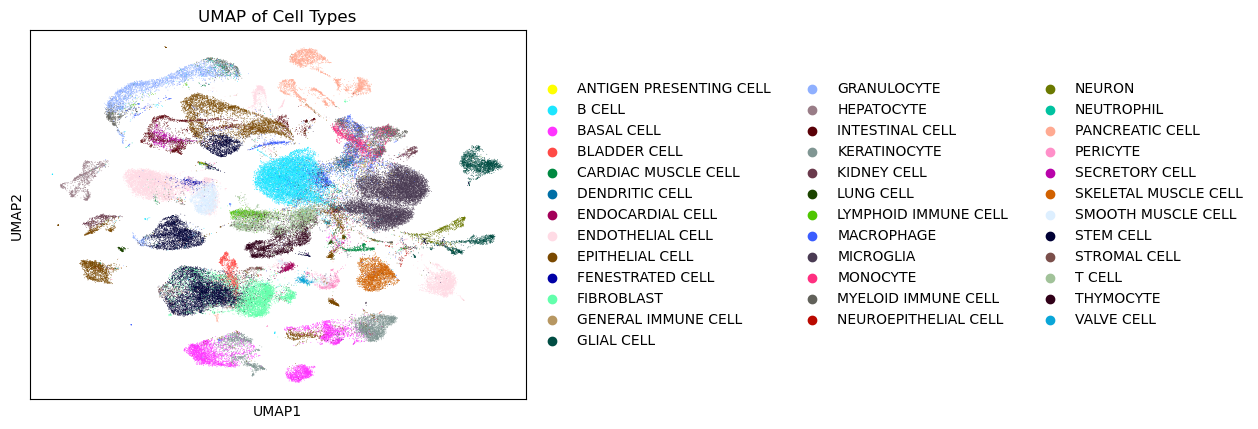

In [31]:
# sanity check UMAP on cell types and age groups
sc.pl.umap(adata_full, color="cell_type_grouped", title="UMAP of Cell Types")

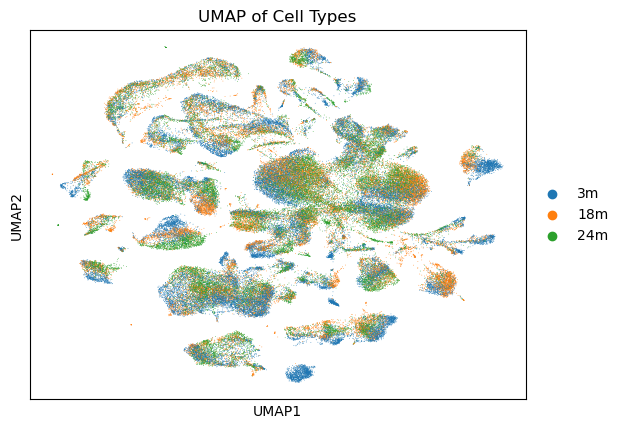

In [32]:
sc.pl.umap(adata_full, color="age", title="UMAP of Cell Types")

### Obtain sparse junction usage ratios! (First filter to keep only junctions with reasonable coverage...)

In [33]:
# Print final number of splice junctions, ATSEs, and genes in splice_adata
print(f"Number of splice junctions: {splice_adata.shape[1]}")
print(f"Number of ATSEs: {splice_adata.var['event_id'].nunique()}")
print(f"Number of genes: {adata_full.shape[1]}")

Number of splice junctions: 14415
Number of ATSEs: 5094
Number of genes: 3812


In [34]:
print(splice_adata.var.splice_motif.value_counts())
print(splice_adata.var.annotation_status.value_counts())

splice_motif
GT-AG    14284
GC-AG      127
AT-AC        4
Name: count, dtype: int64
annotation_status
both           11332
five_prime      1622
three_prime     1421
unannotated       40
Name: count, dtype: int64


In [35]:
# Update junction_counts and cluster_counts
junction_counts = splice_adata.layers["cell_by_junction_matrix"].tocoo()
cluster_counts = splice_adata.layers["cell_by_cluster_matrix"].tocoo()

#### Get sparse PCA, UMAP and Diffusion Map!

In [36]:
# Get sparse centered PSI values 
splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)

# Step 1: Perform PCA using sparse data
n_components = 50  

n_iter = 10  # Increasing the number of iterations for better convergence
svd = TruncatedSVD(n_components=n_components, n_iter=n_iter, random_state=42)

# Fit and transform the junction ratio data (this gives U)
U = svd.fit_transform(splice_adata.layers["junc_ratio"])

# Get the singular values (S)
S = svd.singular_values_

# Multiply U by S to get U * S
U_by_S = U * S  # This scales each component in U by the corresponding singular value in S

# Store the PCA results (U * S) in the 'X_pca' field of .obsm (multi-dimensional)
splice_adata.obsm['X_pca'] = U_by_S

# store explained variance ratio for future reference
splice_adata.uns['pca_explained_variance_ratio'] = svd.explained_variance_ratio_

# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(splice_adata, use_rep='X_pca')

# Step 3. Calculate UMAP 
sc.tl.umap(splice_adata)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


... storing 'cell_ontology_class' as categorical
... storing 'subtissue_clean' as categorical
... storing 'cell_type_grouped' as categorical
... storing 'annotation_status' as categorical
... storing 'gene_name' as categorical
... storing 'gene_id' as categorical
... storing 'old_junction_id_index' as categorical
... storing 'old_junction_id_index' as categorical


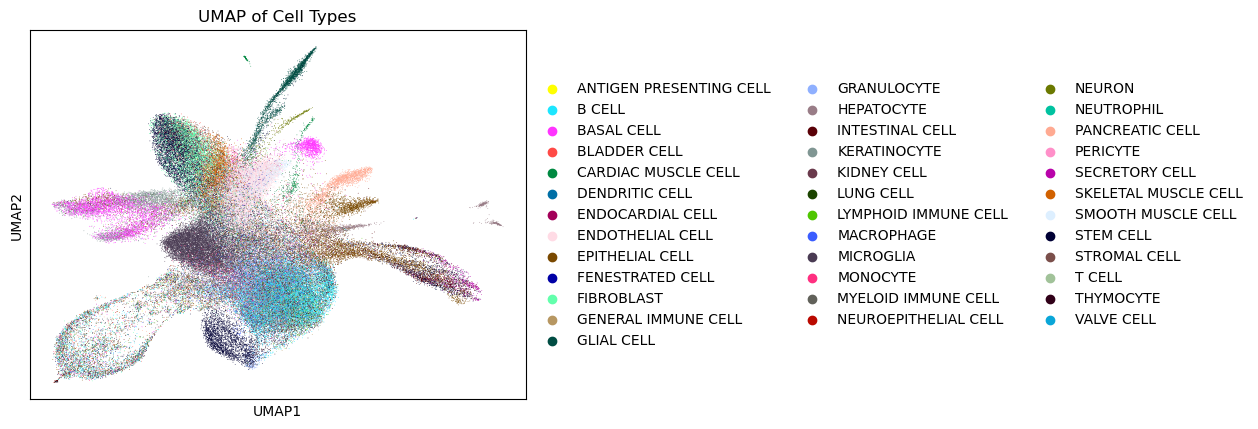

In [37]:
# plot UMAP with cell types and age groups
sc.pl.umap(splice_adata, color="cell_type_grouped", title="UMAP of Cell Types")

... storing 'old_junction_id_index' as categorical
... storing 'old_junction_id_index' as categorical


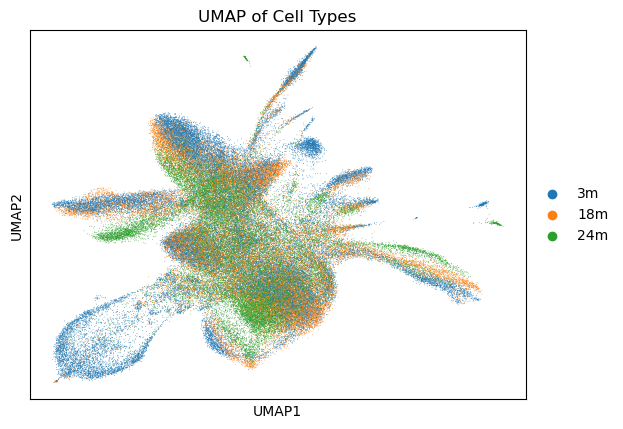

In [38]:
# plot UMAP with cell types and age groups
sc.pl.umap(splice_adata, color="age", title="UMAP of Cell Types")

### Identify cell waypoints using splicing based PCs!

In [39]:
# Define possible number of waypoints to learn
n_waypoints_learn = [30, 100]

# Placeholder to store waypoints and metacell dictionaries for each n_waypoints
waypoints_dict = {}
metacell_dicts = {}

# Parameters
num_components = 50  # Number of components to consider
metacell_size = 50    # Number of nearest cells to assign to each waypoint
pca_components = splice_adata.obsm["X_pca"]

# Loop over different n_waypoints to generate waypoints and metacell assignments
for n_waypoints in n_waypoints_learn:

    print(f"Finding {n_waypoints} waypoints from the PCA components!")
    random_seed = np.random.randint(0, 10000 + 1)  # Generate random seed
    
    # Max-min sampling to identify waypoints
    waypoints = wayp.max_min_sampling(pca_components, n_waypoints, num_components=num_components, seed=random_seed)
    
    # Store waypoints for this particular number of waypoints
    waypoints_dict[n_waypoints] = waypoints

    # Assign nearest cells to each waypoint (metacells)
    metacell_dict = wayp.assign_nearest_cells(waypoints, pca_components, num_nearest=metacell_size)
    
    # Store the metacell dictionary for this number of waypoints
    metacell_dicts[n_waypoints] = metacell_dict

Finding 30 waypoints from the PCA components!
Finding 100 waypoints from the PCA components!


#### Try looking at waypoints just using PC space...

... storing 'old_junction_id_index' as categorical
... storing 'old_junction_id_index' as categorical


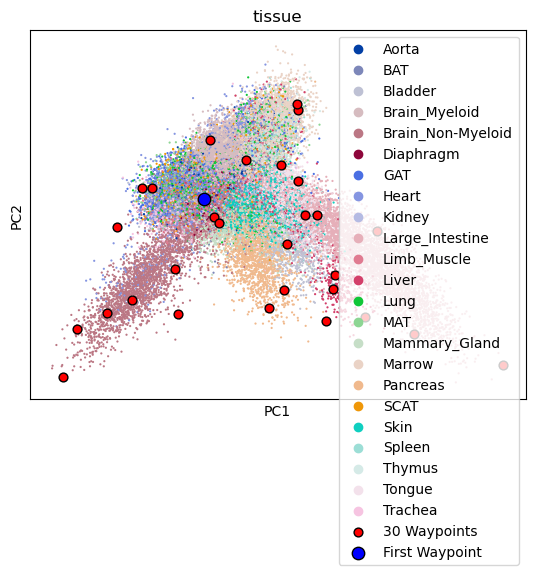

In [40]:
wayp.plot_PCA_with_waypoints(splice_adata, waypoints_dict, n_waypoints=30, waypoint_color='red', first_waypoint_color='blue', size=10)

### Generate_initializations matrices for Phi and Psi

In [41]:
rho_hat = splice_adata.layers["junc_ratio"]

# Generate multiple initializations
psi_initializations, phi_initializations = wayp.generate_initializations(rho_hat, waypoints_dict, metacell_dicts, epsilon=0.001)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Finding 30 waypoints from the diffusion components!


30it [00:02, 12.46it/s]


Finding 100 waypoints from the diffusion components!


100it [00:08, 12.42it/s]


In [42]:
# Loop through the waypoints_dict and corresponding initializations
for i, n_waypoints in enumerate(waypoints_dict.keys()):

    print(f"Adding waypoint based initializations to anndata for {n_waypoints} waypoints!")

    # Extract the corresponding psi and phi initializations
    psi = psi_initializations[i]
    phi = phi_initializations[i]

    # Convert psi and phi to torch tensors if needed
    psi = torch.tensor(psi)
    phi = torch.tensor(phi)

    # Convert to NumPy arrays if psi and phi are torch tensors (just in case)
    if isinstance(psi, torch.Tensor):
        psi = psi.cpu().numpy()  # Convert to NumPy array
    if isinstance(phi, torch.Tensor):
        phi = phi.cpu().numpy()  # Convert to NumPy array

    # Store psi in `adata.varm` and phi in `adata.obsm` with keys based on the number of waypoints
    splice_adata.varm[f'psi_init_{n_waypoints}_waypoints'] = psi  # Store psi with name 'psi_init_{n_waypoints}_waypoints'
    splice_adata.obsm[f'phi_init_{n_waypoints}_waypoints'] = phi  # Store phi with name 'phi_init_{n_waypoints}_waypoints'


Adding waypoint based initializations to anndata for 30 waypoints!
Adding waypoint based initializations to anndata for 100 waypoints!


In [43]:
# remove junc_ratio layer from splice_adata to save memory prior to saving object 
splice_adata.layers.pop("junc_ratio")

<COOrdinate sparse matrix of dtype 'float64'
	with 234823771 stored elements and shape (106182, 14415)>

### Save splice_adata Anndata object

In [44]:
# remove first old_junction_id_index column from splice_adata.var
splice_adata.var.drop(columns=['old_junction_id_index'], inplace=True)

In [45]:
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# Output DIR 
if brain_only:
    output_dir="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025"
    # if dir does not exist create it
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
else:
    output_dir="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/ALL_CELLS/022025"

# in file name include timestamp 
new_filename = f"TMS_Anndata_ATSE_counts_with_waypoints_{timestamp}.h5ad"

# Create the new full file path
new_file_path = os.path.join(output_dir, new_filename)

# Save the AnnData object with the new filename
splice_adata.write_h5ad(new_file_path, compression='gzip')

print(f"AnnData saved as {new_file_path}")

AnnData saved as /gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/ALL_CELLS/022025/TMS_Anndata_ATSE_counts_with_waypoints_20250325_171641.h5ad


### Save Gene Expression based Anndata object! 

In [46]:
# in file name include timestamp 
new_filename = f"TMS_Anndata_GeneExpression_{timestamp}.h5ad"
new_file_path = os.path.join(output_dir, new_filename)
adata_full.write_h5ad(new_file_path, compression='gzip')
print(f"Gene expression Anndata object successfully saved to {new_file_path}")

# write merged_df to a file in the same output directory as the AnnData object 
merged_df_filename = f"TMS_Anndata_GeneCoverage_JunctionCoverage_{timestamp}.csv"
merged_df_file_path = os.path.join(output_dir, merged_df_filename)
merged_df.to_csv(merged_df_file_path, index=False)
print(f"Gene and junction coverage data saved to {merged_df_file_path}")

Gene expression Anndata object successfully saved to /gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/ALL_CELLS/022025/TMS_Anndata_GeneExpression_20250325_171641.h5ad
Gene and junction coverage data saved to /gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/ALL_CELLS/022025/TMS_Anndata_GeneCoverage_JunctionCoverage_20250325_171641.csv
